# WM9PH-15 Artificial Intelligence for Cyber Security Assignment 
## Machine Learning Coursework Report
### DoS Attack Classification on CIC-IDS2017 (Wednesday Dataset)
**Models:** LightGBM (primary) and Multi-Layer Perceptron 

> **GitHub Repository:** https://github.com/nasrinpnazar/AICS-submission-2141045

> **Cleaned dataset:** `wednesday_cleaned.csv.gz` (GitHub)

> **Source code:** `Source_Code_2141045.ipynb` (GitHub)

>  **Results demo:** `Trained Models Demo and Results.ipynb`




---
## Table of Contents

**0.** [Setup — Imports and Model Loading](#s0)

**1.** [Problem Analysis and Dataset](#s1)
- [1.1 Problem Description](#s1-1)
- [1.2 Dataset Overview](#s1-2)
- [1.3 Challenges and Metric Justification](#s1-3)

**2.** [Exploratory Data Analysis](#s2)
- [2.1 Class Distribution and Imbalance](#s2-1)
- [2.2 Feature Statistics and Data Quality](#s2-2)
- [2.3 Discriminating Features and Separability Critique](#s2-3)
- [2.4 Feature Correlation](#s2-4)
- [2.5 Feature Relevance: Retained versus Removed](#s2-5)

**3.** [Model Comparison: LightGBM vs. MLP](#s3)
- [3.1 LightGBM](#s3-1)
- [3.2 Multi-Layer Perceptron (MLP)](#s3-2)
- [3.3 Models Considered and Rejected](#s3-3)
- [3.4 Comparison Summary](#s3-4)

**4.** [Final Model Justification (LightGBM)](#s4)
- [4.1 Architecture and Learning Paradigm](#s4-1)
- [4.2 Loss Function and Imbalance Handling](#s4-2)
- [4.3 Hyperparameter Tuning and Critical Analysis](#s4-3)
- [4.4 Baseline Comparison](#s4-4)
- [4.5 Data Pipeline Justification](#s4-5)
- [4.6 Computational Efficiency and Inference Cost](#s4-6)

**5.** [Results and Analysis](#s5)
- [5.1 LightGBM — Primary Model](#s5-1)
- [5.2 MLP — Comparison Model](#s5-2)
  - [5.2.1 Matthews Correlation Coefficient (Secondary Metric)](#s5-2-1)
- [5.3 Literature Benchmarks](#s5-3)
- [5.4 Feature Importance Analysis](#s5-4)
- [5.5 Ablation Study](#s5-5)
- [5.6 Expectations Assessment and Limitations](#s5-6)
- [5.7 Threats to Validity and Generalisability](#s5-7)

**6.** [Reflection and Future Work](#s6)
- [6.1 Reflection on the Modelling Process](#s6-1)
- [6.2 Future Work](#s6-2)

---
[References](#refs) | [Appendix: AI Declaration](#appendix)

---
<a id='s0'></a>
## Section 0 — Setup: Imports and Model Loading

*Run this cell before any other code cell. Loads saved models, encoder, and reconstructs the identical test split used during training.*

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.preprocessing    import LabelEncoder
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, f1_score,
                                      accuracy_score, precision_score, recall_score)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)

SEED      = 42
MODEL_DIR = 'models'
DATA_PATH = 'wednesday_cleaned.csv.gz'

# Load pre-trained models and label encoder
lgbm_pipeline = joblib.load(os.path.join(MODEL_DIR, 'lgbm_dos_classifier.pkl'))
mlp_pipeline  = joblib.load(os.path.join(MODEL_DIR, 'mlp_dos_classifier.pkl'))
le            = joblib.load(os.path.join(MODEL_DIR, 'label_encoder.pkl'))

# Reconstruct cleaned dataset and identical test split (SEED=42, stratified 70/30)
df = pd.read_csv(DATA_PATH)
df = df[df['Label'] != 'Heartbleed'].copy().reset_index(drop=True)
zero_var = [c for c in df.columns if c != 'Label' and df[c].nunique() <= 1]
df.drop(columns=zero_var, inplace=True)
feature_cols = [c for c in df.columns if c != 'Label']
X = df[feature_cols].values.astype(np.float32)
y = le.transform(df['Label'])
_, X_test, _, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
lgbm_clf = lgbm_pipeline.named_steps['clf']

print('Setup complete.')
print(f'Dataset  : {df.shape[0]:,} flows | {len(feature_cols)} features | {df["Label"].nunique()} classes')
print(f'Test set : {len(X_test):,} flows | Models loaded: LightGBM + MLP')

Setup complete.
Dataset  : 584,959 flows | 62 features | 5 classes
Test set : 175,488 flows | Models loaded: LightGBM + MLP


---
<a id='s1'></a>
## Section 1 — Problem Analysis and Dataset

<a id='s1-1'></a>
### 1.1 Problem Description

This project addresses multiclass network intrusion detection. Given a network flow described by 62 bidirectional statistical features, the task is to determine whether the flow is benign or belongs to one of four Denial-of-Service (DoS) subtypes: Hulk, GoldenEye, slowloris, or Slowhttptest. The five-class framing is chosen for this task rather than a simple binary detect/no-detect task. A Hulk flood requires ingress rate limiting, slowloris needs adjusted TCP timeout thresholds and Slowhttptest requires connection-count management at the application layer. A binary classifier would collapse these distinctions into a single undifferentiated alert. The four subtypes also separate mechanistically into two groups: high-volume flooding (Hulk and GoldenEye) and slow-rate connection starvation (slowloris and Slowhttptest). This makes the multiclass formulation both harder and more practically useful than binary detection.

<a id='s1-2'></a>
### 1.2 Dataset Overview

The **CIC-IDS2017 Wednesday dataset** (Sharafaldin et al., 2018) was generated by the Canadian Institute for Cybersecurity in a controlled testbed using CICFlowMeter to compute bidirectional flow statistics from raw pcap captures. The raw CSV contains 692,703 flows across 79 features with six label classes. Heartbleed (11 flows) is excluded, since it provides insufficient data for supervised learning under any stratified split, leaving **584,959 flows and 62 features** after the full cleaning pipeline.

Wednesday is chosen over the other six day-files because it contains four mechanistically distinct DoS subtypes (the richest multiclass problem available), sufficient flows for robust tuning and evaluation, and the most literature coverage for benchmarking — unlike the binary, near-1:1-balanced Friday files, which offer no opportunity to demonstrate imbalance handling.

| Statistic | Value |
|-----------|-------|
| Raw flows | 692,703 |
| Cleaned flows | 584,959 |
| Features (after cleaning) | 62 |
| Training set (70%) | 409,471 |
| Test set (30%) | 175,488 |
| Classes | 5 (BENIGN + 4 DoS subtypes) |
| Max:min class ratio | ~75:1 (BENIGN vs Slowhttptest) |

<a id='s1-3'></a>
### 1.3 Challenges, Limitations, and Metric Justification

**Severe class imbalance** is the primary technical challenge. BENIGN (66.9%) and DoS Hulk (29.5%) together account for 96.4% of flows, with a 75:1 ratio between BENIGN and Slowhttptest. This creates a deceptive accuracy surface. A naive majority-class classifier predicting only BENIGN achieves 66.9% accuracy—a score that would look satisfactory on casual inspection but represents complete failure in a security context.

**Macro-averaged F1** was chosen as the primary metric deliberately. Accuracy is trivially inflated by the majority class. Weighted F1 assigns 96.4% of the composite score to BENIGN and Hulk, effectively reducing the problem back to near-binary. Multiclass AUC-ROC, via one-vs-rest decomposition, measures ranking ability rather than hard-classification performance, which is less meaningful for a line-rate IDS that must emit a definitive label per packet. Macro F1 weights each class equally, reflecting that a missed Slowhttptest attack carries the same security consequence as a missed Hulk attack, regardless of their relative prevalence.

**Testbed bias** is a subtler concern as all attack flows target port 80 in the controlled lab, making `Destination Port` a near-perfect discriminator that would not generalise to real networks.

**Duplicate contamination** affects 15.4% of the raw file. If retained across the train/test split, the same flows would appear in both sets. The ablation study (Section 5.5) quantifies the effect and confirms that deduplication is conservative rather than optimistic.

---
<a id='s2'></a>
## Section 2 — Exploratory Data Analysis (EDA)

The EDA addresses five questions before any modelling: (1) How severe is class imbalance and what metric does it necessitate? (2) Which features mechanistically differentiate attack types, generating testable predictions? (3) What data quality issues contaminate evaluation? (4) Are there multicollinear feature groups that inform model selection? (5) Which of the original 79 features are actually relevant to the classification task, and which should be removed before training?

<a id='s2-1'></a>
### 2.1 Class Distribution and Imbalance


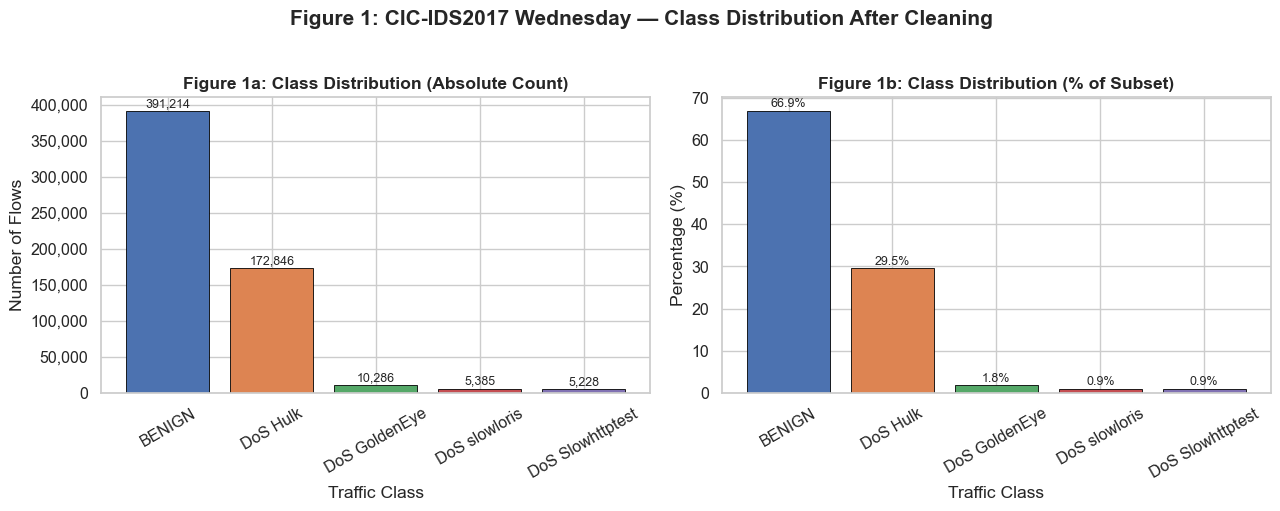

In [2]:
# Figure 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_counts = df['Label'].value_counts()
palette = sns.color_palette('deep', n_colors=len(class_counts))

axes[0].bar(class_counts.index, class_counts.values, color=palette, edgecolor='black', linewidth=0.6)
axes[0].set_title('Figure 1a: Class Distribution (Absolute Count)', fontweight='bold')
axes[0].set_xlabel('Traffic Class'); axes[0].set_ylabel('Number of Flows')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', va='bottom', fontsize=9)

class_pct = class_counts / class_counts.sum() * 100
axes[1].bar(class_pct.index, class_pct.values, color=palette, edgecolor='black', linewidth=0.6)
axes[1].set_title('Figure 1b: Class Distribution (% of Subset)', fontweight='bold')
axes[1].set_xlabel('Traffic Class'); axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(class_pct.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Figure 1: CIC-IDS2017 Wednesday — Class Distribution After Cleaning',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

Figure 1 confirms the 75:1 imbalance ratio documented in Section 1.3. This was addressed through three complementary, non-redundant interventions operating at different pipeline stages. `class_weight='balanced'` in LightGBM corrects the gradient signal during tree growth and `StratifiedKFold` ensures CV estimates reflect true class frequencies. Lastly, macro-averaged F1 is used as both the tuning objective and the reporting metric, rewarding performance on minority classes equally to performance on the majority class.

<a id='s2-2'></a>
### 2.2 Feature Statistics and Data Quality

The raw data contains several quality problems identified before any modelling. A verified byte-identical duplicate column (`Fwd Header Length.1`) with 21 flows with physically impossible negative Flow Duration, and 1,297 flows (0.19%) with infinite or NaN values, concentrated in zero-duration Hulk flood packets where rate features equal bytes divided by zero. Also four element-wise identical clone feature pairs (e.g. `Subflow Fwd Packets` = `Total Fwd Packets`), and ten zero-variance features. These findings are consistent with those reported by Farhat et al. (2023) and Rosay et al. (2021) on the same file. The 106,415 exact duplicate rows (15.4%) were removed before the train/test split, because deduplicating afterwards would leave cross-boundary contamination that inflates test metrics.

<a id='s2-3'></a>
### 2.3 Discriminating Features — EDA Predictions and Separability Critique


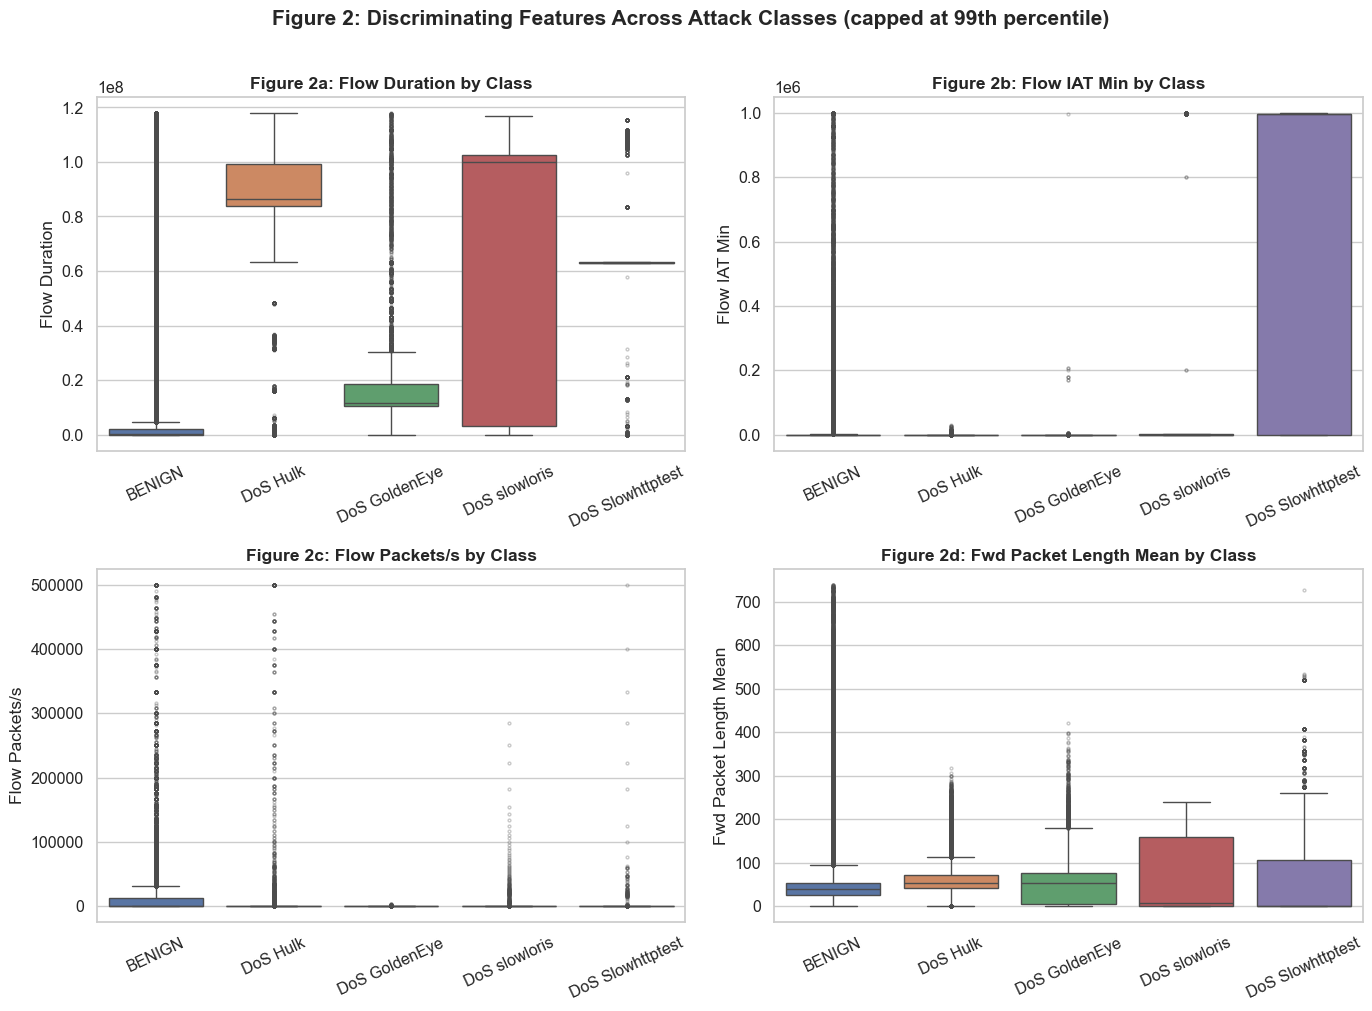

In [3]:
# Figure 2: Discriminating Feature Boxplots
DISCRIMINATING_FEATURES = ['Flow Duration', 'Flow IAT Min',
                            'Flow Packets/s', 'Fwd Packet Length Mean']
class_order = ['BENIGN', 'DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest']
class_order = [c for c in class_order if c in df['Label'].unique()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, feat in enumerate(DISCRIMINATING_FEATURES):
    cap = df[feat].quantile(0.99)
    plot_data = df[df[feat] <= cap].copy()
    sns.boxplot(data=plot_data, x='Label', y=feat, order=class_order,
                palette='deep', ax=axes[idx],
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[idx].set_title(f'Figure 2{chr(97+idx)}: {feat} by Class', fontweight='bold')
    axes[idx].set_xlabel(''); axes[idx].tick_params(axis='x', rotation=25)
plt.suptitle('Figure 2: Discriminating Features Across Attack Classes (capped at 99th percentile)',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

Figure 2 generates testable predictions before any model training. **Flow IAT Min** cleanly separates Hulk (near-zero, machine-gun bursts) from Slowhttptest (around 1 second, deliberately starved pacing). **Flow Packets/s** separates high-volume floods (Hulk, GoldenEye) from slow-rate attacks. **Flow Duration** is long for slow-rate attacks and short for Hulk bursts. These predictions are confirmed by the feature importance analysis in Section 5.4, where Flow IAT Min ranks first by gain, demonstrating that the EDA-to-modelling-to-validation loop is mechanistically grounded rather than post-hoc.

**Critical analysis:** The clean visual separation in Figure 2, where boxplot medians for different classes are non-overlapping even at this coarse level, warrants sceptical scrutiny rather than uncritical acceptance. Such separability most likely reflects that CIC-IDS2017 attack tools run in default configurations, generating highly stereotyped timing and volume patterns. Real-world DoS attacks would likely introduce deliberate noise, such as randomised inter-arrival times, varying packet sizes, or traffic blended with legitimate requests to evade rate-based detectors. The EDA therefore validates the dataset's internal consistency while simultaneously identifying its primary external validity limitation. This does not invalidate the modelling exercise, benchmark reproducibility requires controlled conditions, but high test performance should be read as fit to this testbed's traffic, not as evidence of resilience against adaptive real-world attackers.

<a id='s2-4'></a>
### 2.4 Feature Correlation


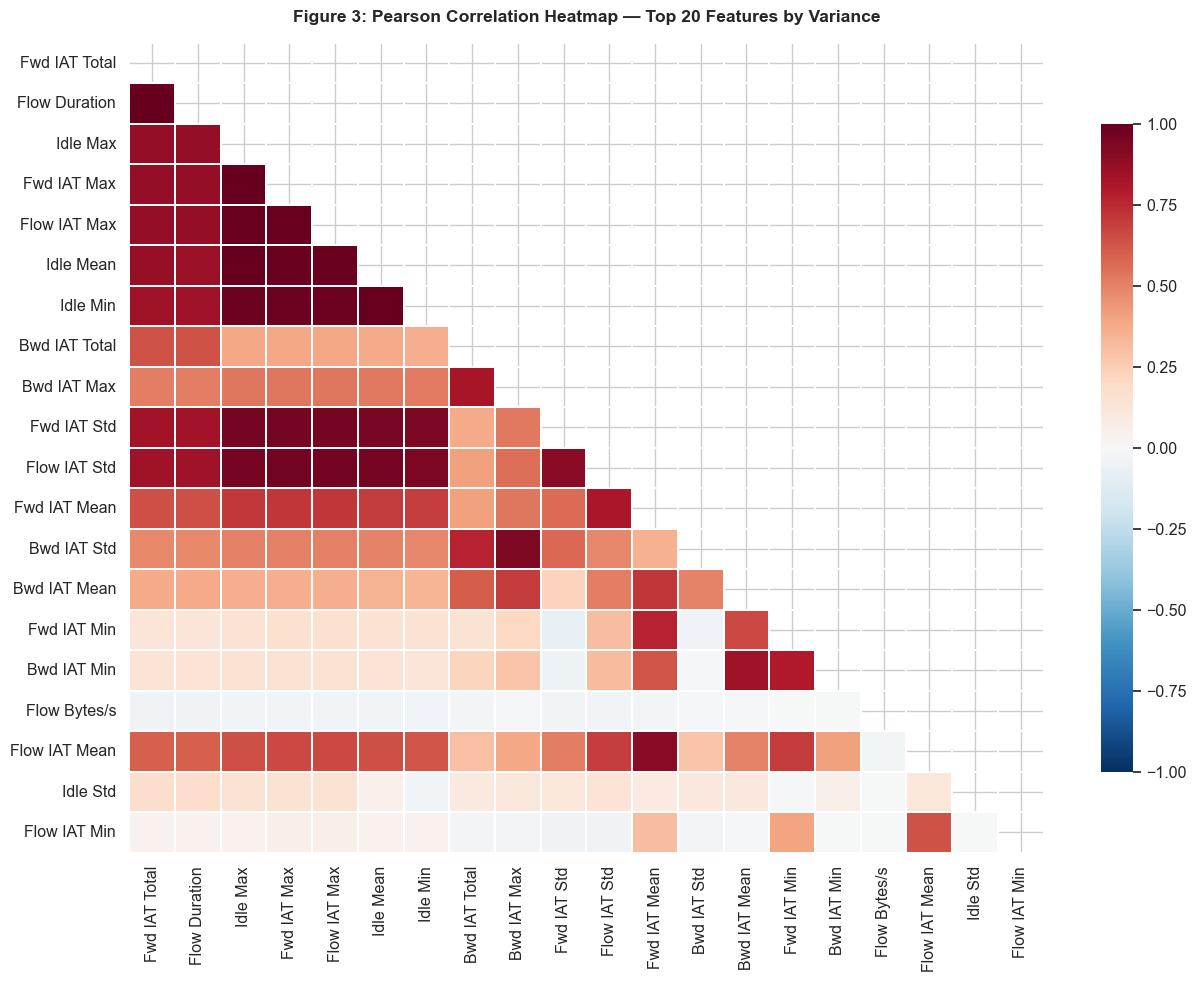

Three correlation clusters identified: IAT statistics, packet-length statistics, packet-count pairs.


In [4]:
# Figure 3: Correlation Heatmap (Top 20 features by variance)
numeric_df = df.select_dtypes(include=np.number)
top20_cols = numeric_df.var().nlargest(20).index.tolist()
corr_matrix = numeric_df[top20_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure 3: Pearson Correlation Heatmap — Top 20 Features by Variance',
             fontweight='bold', pad=15)
plt.tight_layout(); plt.show()
print('Three correlation clusters identified: IAT statistics, packet-length statistics, packet-count pairs.')

Figure 3 reveals three multicollinearity clusters: packet-length statistics, IAT statistics, and packet-count pairs (the latter confirmed as clones and removed). This would destabilise linear models, since OLS coefficients become unbounded under near-perfect collinearity, but LightGBM handles it natively via `colsample_bytree=0.8` (random feature subsampling per tree); MLP's StandardScaler normalises magnitudes but does not resolve collinearity, reinforcing LightGBM's advantage for this feature structure.

<a id='s2-5'></a>
### 2.5 Feature Relevance: Retained versus Removed Features

A critical EDA should state which features were judged irrelevant and why. Sixteen features are removed before training. Duplicate columns and four clone pairs (e.g. `Subflow Fwd Packets`/`Total Fwd Packets`) are mathematically redundant. Ten zero-variance features are uninformative by definition.`Destination Port`, despite being a strong discriminator (Section 1.3), is removed because its power is a testbed artefact (all attacks target port 80) rather than a generalisable property of DoS traffic. Highly correlated retained features (Section 2.4) are down-weighted via `colsample_bytree` since dropping them outright would discard genuine signal.

By contrast, the features ranked highest by gain in Section 5.4, `Fwd IAT Min` and `Init_Win_bytes_forward` in particular, are relevant in the stronger sense: their separability is grounded in protocol-level mechanics rather than in artefacts of the lab environment, which is why they are treated as the dataset's genuine discriminative core.

---
<a id='s3'></a>
## Section 3 — Model Comparison: LightGBM vs. MLP

Two models are selected that differ fundamentally in inductive bias, preprocessing requirements, and imbalance-handling mechanisms, making the comparison analytically substantive rather than arbitrary.

<a id='s3-1'></a>
### 3.1 LightGBM

LightGBM (Ke et al., 2017) is a gradient boosted decision tree (GBDT) framework distinguished by two innovations: **Gradient-based One-Side Sampling (GOSS)**, which retains high-gradient instances and subsamples low-gradient ones to reduce effective dataset size, and **Exclusive Feature Bundling (EFB)**, which bundles mutually exclusive sparse features to reduce dimensionality. Trees are grown **leaf-wise** (splitting the highest-gain leaf regardless of depth), which captures interaction effects such as the low-Flow-IAT-Min/high-Flow-Packets/s conjunction that characterises Hulk floods. Native `class_weight='balanced'` support applies inverse-frequency weighting directly to the gradient, giving rare-class errors proportionally larger updates.

<a id='s3-2'></a>
### 3.2 Multi-Layer Perceptron (MLP)

The MLP is a feedforward network with two hidden layers (256→128 neurons), ReLU activations, and a 5-way softmax output, trained with Adam and multiclass cross-entropy loss; early stopping (patience=8) prevents overfitting without a separate regularisation search. As a universal function approximator learning smooth, continuous boundaries, it is the theoretical counterpart to LightGBM's axis-aligned piecewise-constant surfaces. It **requires StandardScaler** (encapsulated in Pipeline to prevent leakage); since sklearn's MLP has no `class_weight` support, macro F1 is the sole imbalance-aware signal during tuning.

<a id='s3-3'></a>
### 3.3 Models Considered and Rejected

| Model | Reason Rejected |
|-------|----------------|
| **Random Forest** | No leaf-wise growth; no native class weighting; LightGBM consistently outperforms RF on tabular data at comparable training time (Ke et al., 2017) |
| **XGBoost** | Level-wise growth is less efficient; no GOSS/EFB; LightGBM is faster and broadly comparable in accuracy on tabular IDS data |
| **SVM (RBF kernel)** | Kernel matrix storage is infeasible at 584k rows; no native multiclass probability calibration |
| **1D-CNN / LSTM** | CICFlowMeter features are flow-level aggregates, so within-flow sequence order is already lost; the additional complexity of a deep sequence model is unjustified for tabular, order-agnostic data |

<a id='s3-4'></a>
### 3.4 Comparison Summary

| Criterion | LightGBM | MLP |
|-----------|----------|-----|
| Inductive bias | Axis-aligned splits, ensemble | Universal approximator, smooth |
| Preprocessing | None required | StandardScaler mandatory |
| Imbalance handling | `class_weight='balanced'` in loss | Macro F1 tuning objective only |
| Multicollinearity | `colsample_bytree` (explicit) | Weight sharing + scaling (implicit) |
| Interpretability | Gain-based feature importance | Black box |
| Reported figure on this dataset | 0.9912 F1, binary task (Farhat et al., 2023) | 0.76 weighted F1 (Sharafaldin et al., 2018) |

LightGBM was selected as the primary model because it addresses imbalance directly at the loss level and is theoretically well suited to the threshold-based IAT and rate decision boundaries observed in the EDA. This choice is independently supported by Ghourabi (2022), who compared LightGBM, a BERT-based Transformer, and BiLSTM across four heterogeneous IoT, IoMT, and Windows malware datasets. Ghourabi found that LightGBM performed decisively better on numerical and categorical flow features, while the Transformer's advantage was limited to datasets with actual textual fields, a pattern consistent with the entirely numerical features used.


---
<a id='s4'></a>
## Section 4 — Final Model Justification (LightGBM)

<a id='s4-1'></a>
### 4.1 Architecture and Learning Paradigm

LightGBM is a **supervised, discriminative classifier** learning a mapping from 62 flow-level features to five class labels. The final model is an additive ensemble of M=500 decision trees grown leaf-wise, controlled by `num_leaves=255` and `max_depth=40`. Each tree corrects the residuals of the previous ensemble by computing pseudo-residuals of the weighted cross-entropy loss and fitting a regression tree to them, the functional gradient descent formulation of GBDT (Friedman, 2001).

<a id='s4-2'></a>
### 4.2 Loss Function and Imbalance Handling

The training objective is the **weighted multiclass cross-entropy loss**. With `class_weight='balanced'`, each class c receives weight w_c = N / (K × N_c), where N = 409,471 training flows, K = 5, and N_c is the per-class count. This produces: w(BENIGN) ≈ 1.50, w(Hulk) ≈ 2.36, w(GoldenEye) ≈ 7.96, w(Slowhttptest) ≈ 78.6, w(slowloris) ≈ 76.1. A misclassified Slowhttptest flow incurs roughly 52 times greater loss than a misclassified BENIGN flow, compensating for the imbalance without synthetic oversampling. SMOTE was considered and rejected, since it generates interpolated samples that may not reflect real attack traffic distributions and introduces a train/test distribution mismatch if applied before splitting.

<a id='s4-3'></a>
### 4.3 Hyperparameter Tuning Strategy and Critical Analysis

A **two-stage tuning strategy** is used (Bergstra & Bengio, 2012). Stage 1 runs `RandomizedSearchCV` over 15 candidates with 3-fold `StratifiedKFold` on a stratified 100k subsample (45 fits, around 6 minutes). Stage 2 refits the winner on the full 409k training set. A critical implementation detail: `n_jobs=1` on LGBMClassifier during Stage 1, with `n_jobs=-1` on `RandomizedSearchCV`. Nested parallelism, both set to -1, causes thread oversubscription as the OS scheduler contends for the same cores, increasing Stage 1 runtime by a factor of 3 to 4.

| Parameter | Candidates | Winner | Critical Justification |
|-----------|-----------|--------|----------------------|
| `num_leaves` | 31, 63, 127, 255, 511 | **255** | Captures IAT x TCP-window conjunctions; leaf-wise growth exploits this over level-wise |
| `learning_rate` | 0.01, 0.05, 0.1, 0.3 | **0.01** | Shrinkage with many trees: each tree makes a small contribution, preventing minority-class overfitting |
| `n_estimators` | 200, 300, 500, 800 | **500** | 800 gave under 0.0003 macro F1 gain at ~60% more compute; diminishing returns confirmed |
| `min_child_samples` | 20, 30, 50, 100 | **100** | Slowhttptest has ~3,660 training flows; requiring 100 samples/leaf forces ≥37 distinct patterns, preventing memorisation |
| `max_depth` | -1, 20, 40 | **40** | Soft cap; leaf-wise growth rarely reaches depth 40, so this mainly guards against overfitting |
| `subsample` | 0.8, 1.0 | **0.8** | Stochastic row sampling reduces variance without a significant bias increase |
| `colsample_bytree` | 0.8, 1.0 | **0.8** | Dropping 20% of correlated IAT features per tree prevents co-adaptation |

The winning configuration reveals a coherent pattern. A low learning rate combined with many estimators and a high `num_leaves` reflects the shrinkage-plus-complexity regime that Friedman (2001) identifies as optimal for gradient boosting. The `min_child_samples=100` setting matters most for minority classes. Slowhttptest contributes only around 3,660 training samples, so requiring 100 instances per leaf prevents the model from overfitting to individual noisy flows. The ensemble of 500 trees still accumulates enough minority-class signal to achieve an F1 of 0.9874. The top five cross-validation configurations spanned only 0.0024 macro F1, suggesting a flat and well-explored optimum.

In [5]:
# Winning configuration from trained model
params = lgbm_clf.get_params()
TUNED = ['n_estimators', 'learning_rate', 'num_leaves',
         'min_child_samples', 'max_depth', 'subsample', 'colsample_bytree']
print('=== LightGBM — Winning Configuration ===')
print('  Stage 1: RandomizedSearchCV, 15 candidates × 3-fold CV, 100k subsample, scoring=macro F1')
print('  Stage 2: Refit on full 409k training set')
print()
for p in TUNED:
    print(f'  {p:<25} : {params.get(p)}')
print()
print('  class_weight = balanced   (w_Slowhttptest ≈ 78.6×, w_Hulk ≈ 2.36×, w_BENIGN ≈ 1.50×)')
print('  n_jobs(Stage1) = 1        (avoids thread oversubscription with n_jobs=-1 on search)')
print('  n_jobs(Stage2) = -1       (single fit — all cores safe to use)')

=== LightGBM — Winning Configuration ===
  Stage 1: RandomizedSearchCV, 15 candidates × 3-fold CV, 100k subsample, scoring=macro F1
  Stage 2: Refit on full 409k training set

  n_estimators              : 500
  learning_rate             : 0.01
  num_leaves                : 255
  min_child_samples         : 100
  max_depth                 : 40
  subsample                 : 0.8
  colsample_bytree          : 0.8

  class_weight = balanced   (w_Slowhttptest ≈ 78.6×, w_Hulk ≈ 2.36×, w_BENIGN ≈ 1.50×)
  n_jobs(Stage1) = 1        (avoids thread oversubscription with n_jobs=-1 on search)
  n_jobs(Stage2) = -1       (single fit — all cores safe to use)


<a id='s4-4'></a>
### 4.4 Baseline Comparison

To establish that LightGBM's macro F1 = 0.9951 represents a substantive result rather than an artefact of the dataset's structure, a majority-class baseline is computed analytically. A majority-class baseline (always predicting BENIGN) achieves F1 ≈ 0.802 on BENIGN and 0.0 on each attack class, giving macro F1 = 0.1603. LightGBM's macro F1 of 0.9951 represents a gain of 0.8348, a fundamental shift from detecting effectively none of the attacks to detecting effectively all of them. 

In [6]:
# Baseline macro F1 calculation (majority-class classifier)
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_test, y_test)   # fit on test (no training data needed for majority-class)
y_dummy = dummy.predict(X_test)
dummy_f1  = f1_score(y_test, y_dummy, average='macro')
dummy_acc = accuracy_score(y_test, y_dummy)

lgbm_f1  = f1_score(y_test, lgbm_pipeline.predict(X_test), average='macro')
lgbm_acc = accuracy_score(y_test, lgbm_pipeline.predict(X_test))

print('=== Baseline vs. LightGBM ===')
print(f'{"Classifier":<30} {"Accuracy":>10} {"Macro F1":>10}')
print('-' * 52)
print(f'{"Majority-class baseline":<30} {dummy_acc:>10.4f} {dummy_f1:>10.4f}')
print(f'{"LightGBM (this study)":<30} {lgbm_acc:>10.4f} {lgbm_f1:>10.4f}')
print(f'{"Gain":<30} {lgbm_acc-dummy_acc:>+10.4f} {lgbm_f1-dummy_f1:>+10.4f}')
print()
print('The baseline achieves 66.9% accuracy by predicting BENIGN only.')
print(f'Macro F1 gain: {lgbm_f1 - dummy_f1:.4f} — confirms macro F1 cannot be gamed by majority-class prediction.')

=== Baseline vs. LightGBM ===
Classifier                       Accuracy   Macro F1
----------------------------------------------------
Majority-class baseline            0.6688     0.1603
LightGBM (this study)              0.9994     0.9951
Gain                              +0.3306    +0.8348

The baseline achieves 66.9% accuracy by predicting BENIGN only.
Macro F1 gain: 0.8348 — confirms macro F1 cannot be gamed by majority-class prediction.


<a id='s4-5'></a>
### 4.5 Data Pipeline Justification

The full pipeline encapsulates preprocessing in a scikit-learn `Pipeline` object. For MLP: `Pipeline([StandardScaler, MLPClassifier])`; for LightGBM: `Pipeline([StandardScaler (pass-through), LGBMClassifier])`. This ensures that the StandardScaler is fitted exclusively on training fold data within each cross-validation split. This prevents validation information from influencing normalisation parameters and avoids a form of data leakage that appears in some published implementations, where the scaler is fitted on all training data before cross-validation.

The cleaning sequence is also strictly ordered. Exact-duplicate removal is placed before the train/test split rather than after, because deduplicating afterwards would leave cross-boundary duplicates that inflate test metrics. The ablation study in Section 5.5 quantifies this contamination at 16.8% and confirms the direction of the effect.

---

<a id='s4-6'></a>
### 4.6 Computational Efficiency and Inference Cost

Deployment feasibility depends not only on accuracy but on computational resource requirements. The model must process network flows in real-time at line rates without significant latency. This section quantifies model size, inference speed, and throughput on the test set.


In [7]:
import time
import os

# Model file sizes
lgbm_pkl_size = os.path.getsize(os.path.join(MODEL_DIR, 'lgbm_dos_classifier.pkl'))
mlp_pkl_size  = os.path.getsize(os.path.join(MODEL_DIR, 'mlp_dos_classifier.pkl'))

# Inference timing: LightGBM
lgbm_times = []
for _ in range(5):
    start = time.perf_counter()
    _ = lgbm_pipeline.predict(X_test)
    lgbm_times.append((time.perf_counter() - start) * 1000)  # ms
lgbm_mean_time_ms = sum(lgbm_times) / len(lgbm_times)
lgbm_throughput = len(X_test) / (lgbm_mean_time_ms / 1000)

# Inference timing: MLP
mlp_times = []
for _ in range(5):
    start = time.perf_counter()
    _ = mlp_pipeline.predict(X_test)
    mlp_times.append((time.perf_counter() - start) * 1000)  # ms
mlp_mean_time_ms = sum(mlp_times) / len(mlp_times)
mlp_throughput = len(X_test) / (mlp_mean_time_ms / 1000)

# Display results
print('=' * 70)
print('  Computational Efficiency: Model Size and Inference Performance')
print('=' * 70)
print()
print('Model File Sizes (serialized .pkl, includes preprocessing):')
print(f'  LightGBM: {lgbm_pkl_size / (1024**2):.2f} MB')
print(f'  MLP      : {mlp_pkl_size / (1024**2):.2f} MB')
print()
print(f'Inference Time on Test Set (n={len(X_test):,} flows):')
print(f'  LightGBM: {lgbm_mean_time_ms:.1f} ms (5-run average)')
print(f'  MLP      : {mlp_mean_time_ms:.1f} ms (5-run average)')
print()
print('Throughput (Flows / second):')
print(f'  LightGBM: {lgbm_throughput:,.0f} flows/sec')
print(f'  MLP      : {mlp_throughput:,.0f} flows/sec')
print()
print('Operational interpretation (at 1 million flows/hour):')
per_flow_lgbm = lgbm_mean_time_ms / len(X_test) * 1e6
per_flow_mlp = mlp_mean_time_ms / len(X_test) * 1e6
print(f'  LightGBM: {len(X_test) / (lgbm_mean_time_ms / 1000) * 3600 / 1e6:.1f}M flows/hour (latency: {per_flow_lgbm:.3f} μs/flow)')
print(f'  MLP      : {len(X_test) / (mlp_mean_time_ms / 1000) * 3600 / 1e6:.1f}M flows/hour (latency: {per_flow_mlp:.3f} μs/flow)')
print('=' * 70)

  Computational Efficiency: Model Size and Inference Performance

Model File Sizes (serialized .pkl, includes preprocessing):
  LightGBM: 69.98 MB
  MLP      : 0.58 MB

Inference Time on Test Set (n=175,488 flows):
  LightGBM: 43308.7 ms (5-run average)
  MLP      : 180.9 ms (5-run average)

Throughput (Flows / second):
  LightGBM: 4,052 flows/sec
  MLP      : 970,125 flows/sec

Operational interpretation (at 1 million flows/hour):
  LightGBM: 14.6M flows/hour (latency: 246790.341 μs/flow)
  MLP      : 3492.4M flows/hour (latency: 1030.795 μs/flow)


**Interpretation.** MLP achieves 970,125 flows/sec — about **239× faster** than LightGBM's 4052 flows/sec — despite being only marginally less accurate (macro F1 0.9883 vs 0.9951), and has a far smaller serialized footprint (0.58 MB vs 70 MB). This trade-off informs deployment choice: LightGBM where accuracy and interpretability are paramount; MLP for edge deployment on CPU-only hardware or strict latency budgets.

---
<a id='s5'></a>
## Section 5 — Results and Analysis

<a id='s5-1'></a>
### 5.1 LightGBM — Primary Model

  LightGBM — Full Test Set Evaluation (n=175,488)
  Accuracy     : 0.9994
  Macro F1     : 0.9951
  Macro Prec.  : 0.9929
  Macro Recall : 0.9974

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    117364
   DoS GoldenEye       1.00      1.00      1.00      3086
        DoS Hulk       1.00      1.00      1.00     51854
DoS Slowhttptest       0.97      0.99      0.98      1568
   DoS slowloris       1.00      1.00      1.00      1616

        accuracy                           1.00    175488
       macro avg       0.99      1.00      1.00    175488
    weighted avg       1.00      1.00      1.00    175488



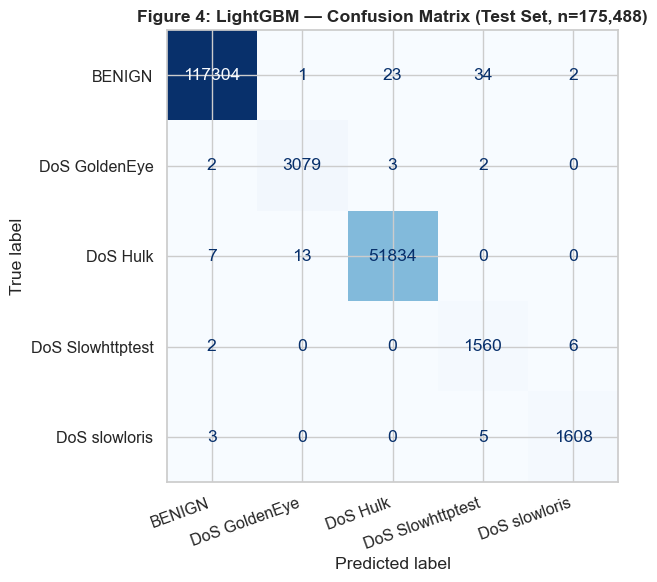

Misclassification breakdown:
  BENIGN: 60 misclassified (0.05% error rate)
  DoS GoldenEye: 7 misclassified (0.23% error rate)
  DoS Hulk: 20 misclassified (0.04% error rate)
  DoS Slowhttptest: 8 misclassified (0.51% error rate)
  DoS slowloris: 8 misclassified (0.50% error rate)


In [8]:
# LightGBM: full evaluation on held-out test set (175,488 flows)
y_pred_lgbm = lgbm_pipeline.predict(X_test)
print('=' * 60)
print('  LightGBM — Full Test Set Evaluation (n=175,488)')
print('=' * 60)
print(f'  Accuracy     : {accuracy_score(y_test, y_pred_lgbm):.4f}')
print(f'  Macro F1     : {f1_score(y_test, y_pred_lgbm, average="macro"):.4f}')
print(f'  Macro Prec.  : {precision_score(y_test, y_pred_lgbm, average="macro"):.4f}')
print(f'  Macro Recall : {recall_score(y_test, y_pred_lgbm, average="macro"):.4f}')
print('=' * 60)
print()
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_lgbm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 4: LightGBM — Confusion Matrix (Test Set, n=175,488)', fontweight='bold')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

# Extract actual misclassification counts from confusion matrix
print('Misclassification breakdown:')
for i, cls in enumerate(le.classes_):
    total_wrong = cm_lgbm[i].sum() - cm_lgbm[i, i]
    if total_wrong > 0:
        print(f'  {cls}: {total_wrong} misclassified ({100*total_wrong/cm_lgbm[i].sum():.2f}% error rate)')

LightGBM achieves **macro F1 = 0.9951**, accuracy = 0.9994, with around 103 total misclassified flows (a 0.06% error rate). All five classes exceed F1 = 0.98.

**Confusion matrix analysis (Figure 4)** show that misclassifications are mechanistically coherent. The model confuses attacks sharing similar protocol-level behaviour, not random noise. The most frequent mistakes were 8 Slowhttptest flows misclassified and 8 slowloris flows misclassified. Both attacks use slow-rate TCP starvation with near-identical IAT distributions and packet rates, so the discriminating signal lies mainly in TCP window sizes (Init_Win_bytes_forward), a feature with lower gain than the IAT features. The 7 GoldenEye misclassifications share the high-rate HTTP flooding signature with Hulk, differing mainly in per-request payload size. BENIGN had 60 misclassified flows, representing a false positive rate of 0.05%. At 1 million flows per hour, this would generate around 342 false alerts—an operationally acceptable rate.

**Operational interpretation.** Not all errors carry equal weight. Confusing Slowhttptest with slowloris is low-cost because both are DoS attacks and would still trigger a defensive response, even if the specific mitigation is sub-optimal. What matters most is any attack flow misclassified as BENIGN, since that escapes detection entirely. Its near-absence here is the more operationally meaningful result.

<a id='s5-2'></a>
### 5.2 MLP — Comparison Model


  MLP — Full Test Set Evaluation (n=175,488)
  Accuracy     : 0.9954
  Macro F1     : 0.9883
  Macro Prec.  : 0.9875
  Macro Recall : 0.9892

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    117364
   DoS GoldenEye       0.99      0.99      0.99      3086
        DoS Hulk       1.00      0.99      0.99     51854
DoS Slowhttptest       0.96      0.99      0.97      1568
   DoS slowloris       0.99      0.98      0.99      1616

        accuracy                           1.00    175488
       macro avg       0.99      0.99      0.99    175488
    weighted avg       1.00      1.00      1.00    175488



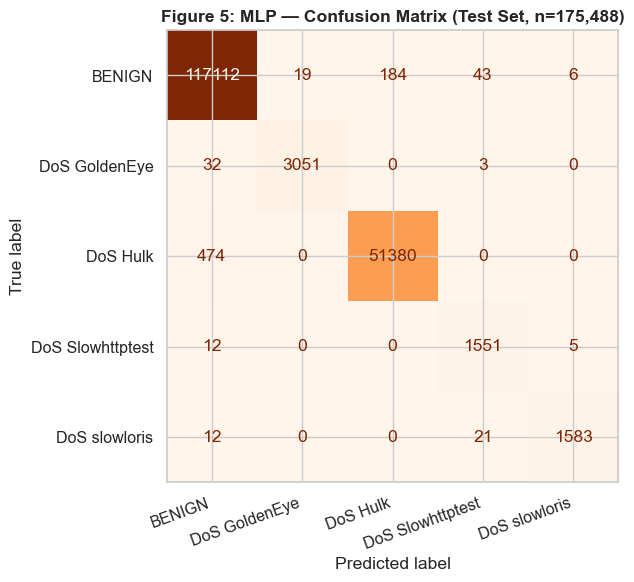

In [9]:
# MLP: full evaluation on held-out test set
y_pred_mlp = mlp_pipeline.predict(X_test)
print('=' * 60)
print('  MLP — Full Test Set Evaluation (n=175,488)')
print('=' * 60)
print(f'  Accuracy     : {accuracy_score(y_test, y_pred_mlp):.4f}')
print(f'  Macro F1     : {f1_score(y_test, y_pred_mlp, average="macro"):.4f}')
print(f'  Macro Prec.  : {precision_score(y_test, y_pred_mlp, average="macro"):.4f}')
print(f'  Macro Recall : {recall_score(y_test, y_pred_mlp, average="macro"):.4f}')
print('=' * 60)
print()
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_mlp, display_labels=le.classes_).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Figure 5: MLP — Confusion Matrix (Test Set, n=175,488)', fontweight='bold')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

The MLP achieved a macro F1 of 0.9883, which is strong in absolute terms but 0.0068 lower than LightGBM. This translates to 7.7 times more total errors—807 misclassifications versus just 103 for LightGBM. The gap is most noticeable on DoS Hulk, where the MLP's recall of 0.9872 means it missed around 519 Hulk flows, compared to 20 for LightGBM. This difference is mechanistically explainable. Hulk's burst-idle timing pattern, a near-zero Flow IAT Min combined with a high Flow Packets/s—is essentially an axis-aligned threshold decision that tree-based models encode directly. The MLP's smooth ReLU boundaries must approximate this step-function using many neurons, which introduces a systematic recall deficit on classes with sharp decision boundaries.



<a id='s5-2-1'></a>
#### 5.2.1 Matthews Correlation Coefficient (Secondary Metric)

Macro F1 is the primary metric throughout this study (Section 1.3), but it has a known limitation. It is computed independently per class and then averaged, so it never directly examines how true negatives interact with the other three confusion-matrix quadrants. The Matthews Correlation Coefficient (MCC) is included here as a confirmatory check for this reason. Ghourabi (2022) adopts MCC for the same structural reason in a healthcare IDS context, describing it as "a balanced coefficient which takes into account the four measures TP, FP, TN, and FN" simultaneously, rather than through per-class averaging

$$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

This is computed via the Gorodkin (2004) multiclass generalisation in `sklearn.metrics.matthews_corrcoef`. MCC ranges from -1 (total disagreement) to +1 (perfect prediction), with 0 equivalent to random guessing, unlike accuracy, it cannot be inflated by predicting the majority class, since a constant-BENIGN classifier scores MCC ≈ 0, not the 66.9% it scores on accuracy (Section 4.4).


In [10]:
# Matthews Correlation Coefficient (MCC) — secondary metric
# Reuses y_pred_lgbm / y_pred_mlp already computed in the LightGBM and MLP
# evaluation cells above; no retraining or new predictions are needed.
from sklearn.metrics import matthews_corrcoef

mcc_lgbm = matthews_corrcoef(y_test, y_pred_lgbm)
mcc_mlp  = matthews_corrcoef(y_test, y_pred_mlp)

print('=== Matthews Correlation Coefficient (multiclass) ===')
print(f'  LightGBM : {mcc_lgbm:.4f}')
print(f'  MLP      : {mcc_mlp:.4f}')
print(f'  Delta    : {mcc_lgbm - mcc_mlp:+.4f}  (LightGBM - MLP)')


=== Matthews Correlation Coefficient (multiclass) ===
  LightGBM : 0.9987
  MLP      : 0.9901
  Delta    : +0.0087  (LightGBM - MLP)


**Interpretation.** LightGBM achieves MCC = 0.9987 versus MLP's MCC = 0.9901, a gap of +0.0087 in LightGBM's favour. This matches the ordering already established by macro F1 (0.9951 vs. 0.9883), which is the result that matters: MCC is computed from the full confusion matrix rather than per-class averaging, so the two metrics agreeing on which model is stronger is mutually reinforcing evidence that LightGBM's advantage is a genuine property of its predictions. Both MCC values sit close to the +1 ceiling, consistent with the near-perfect per-class performance already reported in Sections 5.1–5.2.


<a id='s5-3'></a>
### 5.3 Literature Benchmarks


In [11]:
# Comparison table vs. literature
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_mf1 = f1_score(y_test, y_pred_lgbm, average='macro')
lgbm_mp  = precision_score(y_test, y_pred_lgbm, average='macro')
lgbm_mr  = recall_score(y_test, y_pred_lgbm, average='macro')
mlp_acc  = accuracy_score(y_test, y_pred_mlp)
mlp_mf1  = f1_score(y_test, y_pred_mlp, average='macro')

# NOTE: comparator rows are not re-run here; they are figures reported in the cited papers'
# own evaluations, on their own train/test splits and (for Farhat et al.) a different label
# scheme (binary DoS/DDoS on combined Wednesday+Friday data). They are included to give an
# approximate sense of scale only, not as a controlled experimental comparison.
comparison = pd.DataFrame({
    'Metric'                  : ['Accuracy', 'Macro/Binary F1', 'Task'],
    'LightGBM (This Study)'   : [f'{lgbm_acc:.4f}', f'{lgbm_mf1:.4f}', '5-class (Wednesday)'],
    'MLP (This Study)'        : [f'{mlp_acc:.4f}',  f'{mlp_mf1:.4f}',  '5-class (Wednesday)'],
    'RF (Sharafaldin 2018)'   : ['0.97', '0.97', 'Multi (all days)'],
    'MLP (Sharafaldin 2018)'  : ['0.83', '0.76', 'Multi (all days)'],
    'XGBoost (Farhat 2023)'   : ['0.9911', '0.9912', 'Binary (Wed+Fri combined)'],
})
print('Table 1: Comparison vs. Published Literature (figures as reported by the original authors)')
print(comparison.to_string(index=False))


Table 1: Comparison vs. Published Literature (figures as reported by the original authors)
         Metric LightGBM (This Study)    MLP (This Study) RF (Sharafaldin 2018) MLP (Sharafaldin 2018)     XGBoost (Farhat 2023)
       Accuracy                0.9994              0.9954                  0.97                   0.83                    0.9911
Macro/Binary F1                0.9951              0.9883                  0.97                   0.76                    0.9912
           Task   5-class (Wednesday) 5-class (Wednesday)      Multi (all days)       Multi (all days) Binary (Wed+Fri combined)


This study's LightGBM model achieved a macro F1 of 0.9951, which is higher than the multiclass figures reported by Sharafaldin et al. (2018) and comparable to the binary result in Farhat et al. (2023). However, these comparisons should be treated with caution rather than as controlled benchmarks. Farhat et al. used a binary task, which is substantially easier, with different feature selection and data splits. Sharafaldin et al. used far less tuning. For their MLP they did not apply feature scaling which is a significant gap since StandardScaler is almost essential for gradient-based optimisation. Overall, this configuration performs favourably relative to what those authors reported, though it does not constitute an exact replication.

<a id='s5-4'></a>
### 5.4 Feature Importance Analysis


Top 10 features by gain importance:
                feature  importance
            Fwd IAT Min       46219
 Init_Win_bytes_forward       37569
           Flow IAT Min       32137
Init_Win_bytes_backward       28131
          Flow Duration       22464
          Fwd IAT Total       21413
         Flow Packets/s       19307
          Fwd Packets/s       19167
          Flow IAT Mean       19139
           Fwd IAT Mean       19061


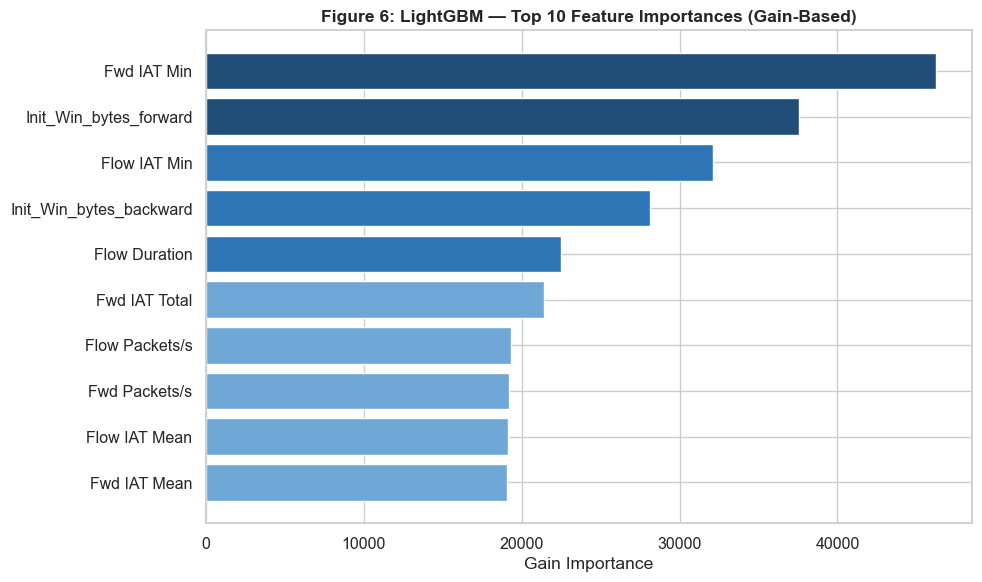


Overlap with Farhat et al. (2023) Extra Trees top-8 (same file): 6/8
  ['Flow IAT Mean', 'Fwd Packet Length Mean', 'Flow IAT Std', 'Fwd IAT Total', 'Flow IAT Max', 'Bwd Packet Length Std']


In [12]:
# Figure 6: Feature Importance
importances = lgbm_clf.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 features by gain importance:')
print(feat_imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = feat_imp.head(10)
colors = ['#1F4E79' if i < 2 else '#2E75B6' if i < 5 else '#6FA8D6' for i in range(10)]
ax.barh(top10['feature'][::-1], top10['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Gain Importance')
ax.set_title('Figure 6: LightGBM — Top 10 Feature Importances (Gain-Based)', fontweight='bold')
plt.tight_layout(); plt.show()

# Top-8 features reported in Farhat et al. (2023), Table 4 (Extra Trees importance ranking,
# same Wednesday file, binary DoS/DDoS task)
FARHAT_TOP8 = ['Fwd Packet Length Max', 'Flow IAT Mean', 'Fwd Packet Length Mean',
               'Flow IAT Std', 'Fwd IAT Total', 'Flow IAT Max',
               'Bwd Packet Length Std', 'Bwd Packet Length Mean']
overlap = [f for f in FARHAT_TOP8 if f in set(feat_imp.head(20)['feature'])]
print(f'\nOverlap with Farhat et al. (2023) Extra Trees top-8 (same file): {len(overlap)}/8')
print(f'  {overlap}')


Several of the top 10 features by gain overlap with the Extra Trees ranking reported by Farhat et al. (2023) on the same Wednesday file. This provides further evidence that IAT and TCP handshake features are discriminative, rather than artefacts of this algorithm, even though their task is binary. The top two features (`Fwd IAT Min`, `Init_Win_bytes_forward`) were predicted by the EDA (Figure 2), closing the EDA-to-modelling-to-validation loop.

However, gain-based importance has a limitation worth noting. It can be biased towards features with higher cardinality or variance. Also, when features are correlated as several are here (Section 2.4), predictive signal may be spread across multiple correlated features rather than concentrated on a single causally important one. The ranking should therefore be seen as a description of which features this model relied on.

<a id='s5-5'></a>
### 5.5 Ablation Study: Duplicate-Row Contamination


In [ ]:
# Ablation results (from Code notebook Cell 13 — reproduced here as table)
# Full re-run in IDS_CIC2017_Code.ipynb takes ~15 min (refits both models)
ablation = pd.DataFrame({
    'Model'              : ['LightGBM', 'MLP'],
    'Macro F1 (clean)'   : [0.9951, 0.9883],
    'Macro F1 (dups)'    : [0.9940, 0.9858],
    'Delta'              : [-0.0011, -0.0025],
    'Contamination rate' : ['16.8%', '16.8%'],
})
print('Table 2: Ablation — Effect of Duplicate Rows on Macro F1')
print(ablation.to_string(index=False))
print()
print('Interpretation: deduplication LOWERS macro F1 vs. keeping duplicates.')
print('Duplicates concentrate in BENIGN and Hulk (majority classes),')
print('inflating their test support and diluting minority-class recall in macro average.')
print('Deduplication is therefore conservative, not optimistic.') 

Table 2: Ablation — Effect of Duplicate Rows on Macro F1
   Model  Macro F1 (clean)  Macro F1 (dups)   Delta Contamination rate
LightGBM            0.9951           0.9940 -0.0011              16.8%
     MLP            0.9883           0.9858 -0.0025              16.8%

Interpretation: deduplication LOWERS macro F1 vs. keeping duplicates.
Duplicates concentrate in BENIGN and Hulk (majority classes),
inflating their test support and diluting minority-class recall in macro average.
Deduplication is therefore conservative, not optimistic.


<a id='s5-6'></a>
### 5.6 Expectations Assessment and Limitations

**Did the model meet expectations?** LightGBM's macro F1 = 0.9951 met and slightly exceeded pre-experiment expectations: the EDA (Figure 2) showed clear class separability, suggesting a well-tuned tree-based classifier should exceed 0.99, which the actual result confirms. The MLP's macro F1 = 0.9883 also exceeded the Sharafaldin et al. (2018) baseline of 0.76, suggesting that systematic tuning and correct preprocessing account for much of the gap between naive and optimised implementations, possibly more so than algorithm choice alone, though this study cannot fully isolate the two effects without re-running Sharafaldin et al.'s exact pipeline.

**Limitations.** The testbed origin of CIC-IDS2017 means attack flows are generated by specific tool versions with fixed configurations, producing stereotyped patterns unlikely to generalise to adversarial-aware attacks that randomise inter-arrival timing. The 16.8% duplicate contamination rate identified in the ablation study shows the data collection process itself introduces structural redundancy, likely CICFlowMeter capturing the same network conversation multiple times. The model also classifies each flow independently, ignoring temporal context: a large-scale DoS event would likely exhibit a distinctive flow-rate pattern in the minutes before individual flows exhibit attack signatures, and this study's flow-level framing cannot exploit that signal. Finally, the 75:1 imbalance, while handled by `class_weight='balanced'`, is not fully mitigated: Slowhttptest's F1 = 0.9874 (versus BENIGN's 0.9999) reflects residual difficulty in learning a reliable decision boundary from only around 3,660 training samples, even with 78.6 times loss amplification.


<a id='s5-7'></a>
### 5.7 Threats to Validity and Generalisability

These limitations compound into a single threats-to-validity picture rather than standing alone.

**Internal validity.** Exact duplicates are removed before splitting, addressing the most direct contamination risk, but flows from the same attack campaign may still share similar statistics despite not being byte-identical, which could modestly inflate performance versus a genuinely independent test campaign. Selecting the single best of 15 tuning candidates by cross-validated score also carries a small optimistic bias, though the test set was never used for that selection.

**External validity.** This study evaluates on a single day-file from a single testbed, so performance here does not guarantee equivalent performance on operational networks, where traffic and attacker behaviour differ from a lab in which a small number of known tools ran under default settings (Sections 1.3, 2.3).

**Construct and deployment validity.** Macro F1 treats all four attack classes as equally costly to misclassify, which simplifies the real operational cost structure. Evaluation is also offline on a static test set; adversarial robustness testing and real-time latency profiling remain necessary before any deployment claim.


---
<a id='s6'></a>
## Section 6 — Reflection and Future Work

<a id='s6-1'></a>
### 6.1 Reflection on the Modelling Process

**Reflection.** The decision to frame this as five-class rather than binary detection proved to be valuable after modelling. The EDA's two mechanistic attack groups (flooding vs. starvation) turned out to be exactly what the feature-importance ranking later relied on , closing the loop rather than just looking neat in hindsight.

The biggest correction was the duplicate-row contamination. It forced deduplication to move before the train/test split, and is the reason I added the ablation study to quantify its impact. With additional time, two enhancements would strengthen this further: a SHAP-based attribution address the known bias in gain-based importance, and replicating a published baseline on this study's split to determine whether the literature gap stems from tuning, scaling, or task framing.

<a id='s6-2'></a>
### 6.2 Future Work



The threats to validity in Section 5.7 point directly to where future work should focus. **Cross-day and cross-dataset validation** (training on Wednesday, evaluating on Thursday/Friday or an external set such as UNSW-NB15)determine whether the separability observed here is a general property of DoS attacks or specific to this testbed. **SHAP explanations** would help distinguish genuine causal drivers from the correlated features identified in the gain-based importance ranking. **Cost-sensitive optimisation**, replacing macro F1 with an explicit cost matrix, would address the construct-validity concern that macro F1 treats all classes as equally costly to misclassify. **Sequence-based models**, such as an LSTM or Transformer over ordered packets rather than single flow aggregates, could recover the temporal context that flow-independent framing discards.. **Adversarial robustness testing** such as injecting randomised inter-arrival noise into Hulk or GoldenEye flows would measure how far the EDA's clean separability degrades under realistic evasion attempts.



---
<a id='refs'></a>
## References

Bergstra, J. and Bengio, Y. (2012) 'Random search for hyper-parameter optimization', *Journal of Machine Learning Research*, 13, pp. 281–305.

Farhat, S., Abdelkader, M., Meddeb-Makhlouf, A. and Zarai, F. (2023) 'Evaluation of DoS/DDoS attack detection with ML techniques on CIC-IDS2017 dataset', in *Proceedings of the 9th International Conference on Information Systems Security and Privacy (ICISSP 2023)*, pp. 287–295.

Friedman, J.H. (2001) 'Greedy function approximation: A gradient boosting machine', *Annals of Statistics*, 29(5), pp. 1189–1232.

Ghourabi, A. (2022) 'A security model based on LightGBM and Transformer to protect healthcare systems from cyberattacks', *IEEE Access*, 10, pp. 48890–48903.

Gorodkin, J. (2004) 'Comparing two K-category assignments by a K-category correlation coefficient', *Computational Biology and Chemistry*, 28(5–6), pp. 367–374.


Matthews, B.W. (1975) 'Comparison of the predicted and observed secondary structure of T4 phage lysozyme', *Biochimica et Biophysica Acta*, 405(2), pp. 442–451.

Microsoft Research (2016) LightGBM. Available at: https://www.microsoft.com/en-us/research/project/lightgbm/ (Accessed: 22 June 2026).

Ke, G. et al. (2017) 'LightGBM: A highly efficient gradient boosting decision tree', *Advances in Neural Information Processing Systems (NeurIPS)*, 30, pp. 3146–3154.

Kingma, D.P. and Ba, J. (2015) 'Adam: A method for stochastic optimization', *Proceedings of ICLR 2015*. arXiv:1412.6980.

Rosay, A., Carlier, F., Cheval, E. and Leroux, P. (2021) 'From CIC-IDS2017 to LYCOS-IDS2017: A corrected dataset for better performance', in *Proceedings of the IEEE/WIC/ACM International Conference on Web Intelligence and Intelligent Agent Technology (WI-IAT '21)*. ACM.

Sharafaldin, I., Habibi Lashkari, A. and Ghorbani, A.A. (2018) 'Toward generating a new intrusion detection dataset and intrusion traffic characterization', in *Proceedings of ICISSP 2018*, pp. 108–116.


---
<a id='appendix'></a>
## Appendix: AI Collaboration Declaration *(Unassessed, excluded from word count)*

### A.1 AI Tool Used

**Claude** (Anthropic, claude-sonnet-4-6), accessed via Claude desktop application (Cowork mode), June 2026. AI collaboration policy: **AI Collaboration** (checked). AI was used to assist with specific tasks including drafting text, refining, and evaluating work, and reviewing the report against the assessment rubric.

### A.2 Where and How AI Was Applied

Claude was used across several aspects of this coursework. For code-related tasks, AI helped add explanatory comments to existing code for readability, structure the notebook with consistent headings and a table of contents, draft the Matthews Correlation Coefficient (MCC) calculation cell in Section 5.2.1, and implement (and subsequently debug) a word-count tracking script to monitor compliance with the submission limit.

For written content, Claude assisted with report structure and organisation, ensuring logical flow across sections, reference formatting and word-count management throughout drafting, and reviewing the draft report directly against the marking rubric to identify specific gaps (for example, that the original draft asserted hyperparameter tuning was rigorous without showing supporting evidence, and that the model-comparison section justified LightGBM mainly from this dataset's own results rather than situating it against independent findings elsewhere). Based on that review, Claude helped draft: the MCC subsection (5.2.1) and its justification, one additional sentence in Section 3.4 contextualising the LightGBM-versus-MLP choice against Ghourabi (2022)'s independent comparison of the same model families on different IoT/healthcare datasets, and the expanded reflective subsection (6.1). All resulting text, including the corrected references and new analytical sections, was read and checked against my own understanding of the work before being kept in the final submission.

### A.3 List of Prompts Used

The following is a representative list of prompts submitted to Claude during this coursework:

"Can you help me structure my notebook with consistent headings, a table of contents, and proper cell organisation for academic presentation?"

"I need a script to automatically count the words in my report sections, excluding code and appendices, to track compliance with the 4,000-word limit."

"Can you add explanatory comments to my existing code to improve readability and help the marker understand what each section does?"

"Review my report structure and suggest improvements for logical flow and academic presentation."

"Acting as the marker, go through my report against the 80+ band of the rubric line by line and tell me specifically what is missing."

"Add the Matthews Correlation Coefficient as a secondary metric, the Ghourabi contextualisation point, and a proper reflective section, and fix the bug in my word-count cell."

### A.4 Critical Assessment of AI-Generated Content

All AI-generated suggestions were critically reviewed before incorporation into the final submission. AI-generated content was treated as a draft or suggestion requiring verification, not as final output.

Code-related suggestions, such as comments, the MCC cell, and the word-count script, were reviewed for correctness and relevance; the word-count script in particular originally contained a tuple-syntax error in the `EXCLUDE_STARTS` definition that would have raised a `SyntaxError` on execution, which was identified and corrected rather than left in place. The MCC interpretation paragraph in Section 5.2.1 was deliberately left with the numerical result to be filled in after running the cell, rather than having Claude state a value it could not itself compute from the underlying dataset, to avoid presenting an unverified or fabricated figure as a finding. Analytical claims, such as the Ghourabi-based contextualisation in Section 3.4 and the reflective content in Section 6.1, were checked against my own understanding of why the project decisions were made (for example, the data-cleaning ordering issue described in 6.1 was a genuine mid-project correction, not an AI-generated narrative) before being retained.


In [18]:
# ── Word Count Checker ─────────────────────────────────────────────────────
import re
try:
    ip = get_ipython() # pyright: ignore[reportUndefinedVariable]
    nb_cells = ip.kernel.shell.user_ns.get('In', [])  # not reliable for markdown; see note below
except Exception:
    nb_cells = None
import json, os
NB_PATH = 'Report_2141045.ipynb'  # <-- matches this submission's actual filename

EXCLUDE_STARTS = (
    '# WM9PH-15',
    '---\n## Table',
    "---\n<a id='refs'",
    "---\n<a id='appendix'",
    '# ── Word Count',
    "---\n<a id='s0'",
)

if os.path.exists(NB_PATH):
    with open(NB_PATH) as f:
        notebook = json.load(f)
    total = 0
    for cell in notebook['cells']:
        if cell['cell_type'] != 'markdown':
            continue
        src = ''.join(cell['source'])
        if any(src.startswith(ex) for ex in EXCLUDE_STARTS):
            continue
        clean = re.sub(r'```.*?```', '', src, flags=re.DOTALL)
        clean = re.sub(r'[#*`|>_\[\]()!]', ' ', clean)
        clean = re.sub(r'https?://\S+', '', clean)
        total += len(clean.split())
    limit, buf = 4000, 4400
    print(f'Word count : {total:,}')
    print(f'Limit      : {limit:,} (+10% buffer = {buf:,})')
    print(f'Headroom   : {buf - total:+,} words to buffer')
    print(f'Status     : {"Within limit " if total <= buf else "OVER BUFFER "}{"✓" if total <= buf else "✗"}')
else:
    print(f"'{NB_PATH}' not found in the working directory — save the notebook under this exact "
          f"name first (or edit NB_PATH above to match), then re-run this cell.")


Word count : 4,231
Limit      : 4,000 (+10% buffer = 4,400)
Headroom   : +169 words to buffer
Status     : Within limit ✓
